Ref:

https://medium.com/@venugopal.adep/transfer-learning-with-vgg16-for-image-classification-cats-vs-dogs-bbe0e895045b

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [ ]:
train_dir = '/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train'
test_dir  = '/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test'

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
batch_size = 32
img_size = (224, 224)

In [ ]:
# Load VGG16 without the top layer (fully connected layers)
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the convolutional base so that it's not trained again
vgg_base.trainable = False

# Summary of the VGG16 base model
vgg_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Create a new model by adding custom layers to the VGG16 base
model = Sequential()
model.add(vgg_base)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,610 (64.14 MB)

 Trainable params: 2,097,922 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Set up data augmentation for training images
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values between 0 and 1
    rotation_range=15,     # Randomly rotate images by 15 degrees
    width_shift_range=0.1, # Randomly shift images horizontally
    height_shift_range=0.1,# Randomly shift images vertically
    zoom_range=0.1,        # Randomly zoom in images
    horizontal_flip=True   # Randomly flip images horizontally
)


In [ ]:
# Only rescale the validation images
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data using flow_from_directory (you need a directory of images)
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train',  # Directory with training images
    target_size=(150, 150), # Resize all images to 150x150
    batch_size=32,
    class_mode='categorical' # Class mode for categorical labels
)

validation_generator = val_datagen.flow_from_directory(
    '/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test',  # Directory with validation images
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1127s 358ms/step - accuracy: 0.8218 - loss: 0.4027 - val_accuracy: 0.8351 - val_loss: 0.3784
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 732s 234ms/step - accuracy: 0.8645 - loss: 0.3249 - val_accuracy: 0.8884 - val_loss: 0.2677
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 728s 233ms/step - accuracy: 0.8707 - loss: 0.3120 - val_accuracy: 0.8866 - val_loss: 0.2677
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 745s 234ms/step - accuracy: 0.8737 - loss: 0.3053 - val_accuracy: 0.8940 - val_loss: 0.2588
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 735s 235ms/step - accuracy: 0.8772 - loss: 0.2955 - val_accuracy: 0.8978 - val_loss: 0.2476
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 729s 233ms/step - accuracy: 0.8817 - loss: 0.2912 - val_accuracy: 0.9010 - val_loss: 0.2422
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 732s 234ms/step - accuracy: 0.8814 - loss: 0.2899 - val_accuracy: 0.9000 - val_loss: 0.2443
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 727s 232ms/step - a

In [ ]:
model.save("deepfake_vgg16_model.h5")

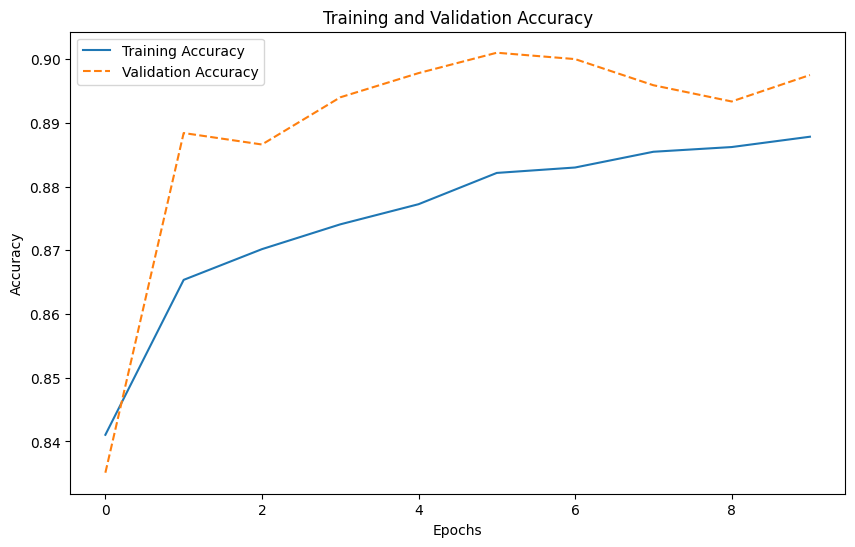

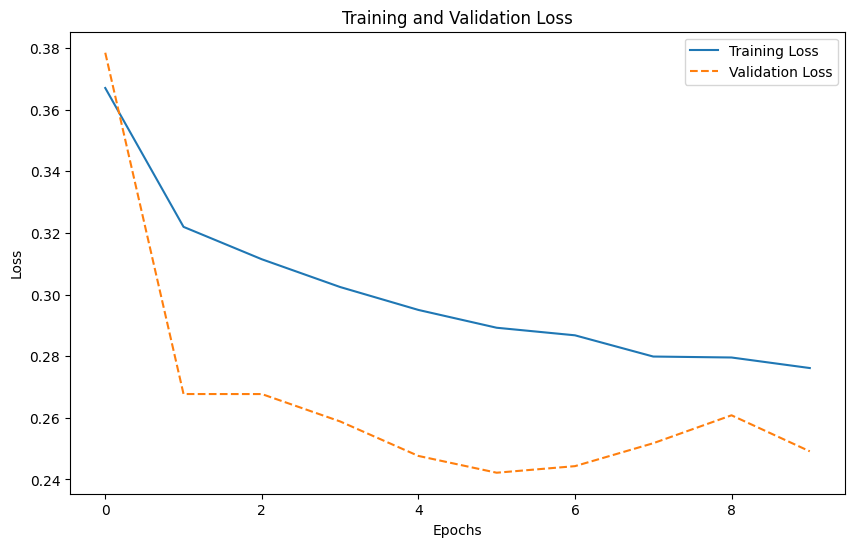

In [ ]:
import pandas as pd

# Convert the history to a DataFrame for easy visualization
history_df = pd.DataFrame(history.history)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], linestyle='--', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], linestyle='--', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("deepfake_vgg16_model.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 9k.jpeg to 9k.jpeg


In [ ]:
import cv2
import numpy as np

def predict_image(image_path):
    # Read image
    img = cv2.imread(image_path)
    img = cv2.resize(img, (150, 150))

    # Normalize
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img)[0][0]

    # Output
    if pred > 0.5:
      print("REAL (1)")
      print(pred)
    else:
      print("FAKE (0)")
      print(pred)

In [ ]:
for fn in uploaded.keys():
    print("Testing:", fn)
    predict_image(fn)

Testing: 9k.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
REAL (1)
1.0
